# External Experimental Trend Validation

This notebook converts the literature experimental `k2` / `kq` values to Eyring activation free energies, adds the two experimental chloride substrates (Cl 723 and 724) to an augmented working ASE database, builds their descriptors following the same database-building logic used in `3_Build_DataBase.ipynb`, and validates the `5_Modeling.ipynb` CatBoost barrier model against the external experimental trends.


In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import math
import pickle
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from ase import Atoms
from ase.db import connect
from catboost import CatBoostRegressor
from matplotlib import pyplot as plt
from rdkit import Chem
from scipy.stats import kendalltau, pearsonr, spearmanr

from DFTStructureGenerator import borane_xat_workflow
from DFTStructureGenerator.descriptor import (
    DUPLICATE_CL_IDS,
    _build_cl_descriptor,
    dataframe_to_descriptors,
    load_descriptor_maps,
    save_descriptor_maps,
)
from DFTStructureGenerator.logfile_process import Logfile
from DFTStructureGenerator.project_paths import (
    CSV_DIR,
    DESCRIPTOR_DIR,
    FIGURE_DIR,
    TS_DATA_DIR,
    raw_calc_file,
    repo_path,
)

warnings.filterwarnings("ignore")
np.random.seed(0)


In [2]:
DB_PATH = repo_path("BorylXAT-DB.db")
EXPERIMENT_CSV_PATH = CSV_DIR / "Experiment.csv"
CL_CSV_PATH = CSV_DIR / "reactants_Cl.csv"
TRAINING_CSV_PATH = TS_DATA_DIR / "Borane_all.csv"

DFT_BN_DESCRIPTOR_PATH = DESCRIPTOR_DIR / "BNdes_new2.pkl"
DFT_CL_DESCRIPTOR_PATH = DESCRIPTOR_DIR / "Cldes_new2.pkl"

OUTPUT_DIR = repo_path("output") / "jacs_experiment"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
AUGMENTED_DB_PATH = OUTPUT_DIR / "BorylXAT-DB_with_jacs_experiment.db"
AUGMENTED_BN_DESCRIPTOR_PATH = OUTPUT_DIR / "BNdes_jacs_experiment.pkl"
AUGMENTED_CL_DESCRIPTOR_PATH = OUTPUT_DIR / "Cldes_jacs_experiment.pkl"

TEMPERATURE_K = 298.15
STANDARD_CONCENTRATION_M = 1.0
R_KCAL_MOL_K = 0.00198720425864083
K_B_J_K = 1.380649e-23
H_J_S = 6.62607015e-34

REBUILD_AUGMENTED_DB = False
SAVE_AUGMENTED_DESCRIPTORS = True

MODEL_PARAMS = dict(
    iterations=10000,
    learning_rate=0.01,
    depth=6,
    verbose=0,
    random_state=0,
    thread_count=4,
    allow_writing_files=False,
)

EXPERIMENTAL_CL_ROWS = [
    {
        "Smiles": "O=C(Nc1ccc(F)cc1)C(Cl)(Cl)Cl",
        "Index": 723,
        "Atomid": 11,
        "E_energy_r": -1918.279800,
        "G_energy_r": -1918.203235,
        "conf_idxs_r": 0,
        "E_energy_p": -1458.034573,
        "G_energy_p": -1457.959129,
        "conf_idxs_p": 0,
        "deltaE_react": 460.245227,
        "deltaG_react": 460.244106,
        "BDE_G": 50.338050,
        "Experiment": 1,
    },
    {
        "Smiles": "O=C(Nc1ccc(F)cc1)C(Cl)Cl",
        "Index": 724,
        "Atomid": 11,
        "E_energy_r": -1458.690747,
        "G_energy_r": -1458.601733,
        "conf_idxs_r": 0,
        "E_energy_p": -998.431560,
        "G_energy_p": -998.344715,
        "conf_idxs_p": 0,
        "deltaE_react": 460.259187,
        "deltaG_react": 460.257018,
        "BDE_G": 58.440330,
        "Experiment": 1,
    },
]

B_LABELS = {388: "BH3", 389: "B(C#N)H2"}
LB_LABELS = {234: "DMAP", 146: "NHC"}
CL_LABELS = {723: "CCl3 amide", 724: "CHCl2 amide"}


## Convert Experimental Rates to Barriers

The experimental file stores the second-order rate constants as `k2` or `kq`. For comparison with computed barriers, the notebook converts them with the Eyring expression for a bimolecular rate constant at a 1 M standard state:

\[\Delta G^{\ddagger}_{\mathrm{exp}} = RT\ln\left(\frac{k_B T / h}{k_2 C^\circ}\right)\]


In [3]:
def rate_to_barrier_kcal(k2, temperature_K=TEMPERATURE_K, standard_concentration_M=STANDARD_CONCENTRATION_M):
    k2 = float(k2)
    if k2 <= 0:
        raise ValueError(f"k2 must be positive, got {k2}")
    pre_exponential = K_B_J_K * temperature_K / H_J_S
    return R_KCAL_MOL_K * temperature_K * math.log(
        pre_exponential / (k2 * standard_concentration_M)
    )

exp_df = pd.read_csv(EXPERIMENT_CSV_PATH)
rate_column = next((col for col in ["k2", "kq", "k2_M-1_s-1"] if col in exp_df.columns), None)
if rate_column is None:
    raise KeyError("Experiment.csv must contain a k2, kq, or k2_M-1_s-1 column")

exp_df = exp_df.copy()
exp_df["k2_M-1_s-1"] = exp_df[rate_column].astype(float)
exp_df["log10_k2"] = np.log10(exp_df["k2_M-1_s-1"])
exp_df["deltaGa_exp(kcal/mol)"] = exp_df["k2_M-1_s-1"].map(rate_to_barrier_kcal)
exp_df["B_label"] = exp_df["B_Index"].map(B_LABELS).fillna(exp_df["B_Index"].astype(str))
exp_df["LB_label"] = exp_df["N_Index"].map(LB_LABELS).fillna(exp_df["N_Index"].astype(str))
exp_df["Cl_label"] = exp_df["Cl_Index"].map(CL_LABELS).fillna(exp_df["Cl_Index"].astype(str))
exp_df["system_label"] = (
    exp_df["B_label"] + " / " + exp_df["LB_label"] + " / " + exp_df["Cl_label"]
)

exp_df[[
    "system_label",
    "B_Index",
    "N_Index",
    "Cl_Index",
    "k2_M-1_s-1",
    "log10_k2",
    "deltaGa_exp(kcal/mol)",
]]


,system_label,B_Index,N_Index,Cl_Index,k2_M-1_s-1,log10_k2,deltaGa_exp(kcal/mol)
0,BH3 / DMAP / CCl3 amide,388,234,723,390000000.0,8.591065,5.732835
1,BH3 / DMAP / CHCl2 amide,388,234,724,37000000.0,7.568202,7.128273
2,BH3 / NHC / CCl3 amide,388,146,723,250000000.0,8.397940,5.996305
3,BH3 / NHC / CHCl2 amide,388,146,724,42000000.0,7.623249,7.053174
4,B(C#N)H2 / DMAP / CCl3 amide,389,234,723,290000000.0,8.462398,5.908368
5,B(C#N)H2 / DMAP / CHCl2 amide,389,234,724,13000000.0,7.113943,7.747994
6,B(C#N)H2 / NHC / CCl3 amide,389,146,723,8400000.0,6.924279,8.006742
7,B(C#N)H2 / NHC / CHCl2 amide,389,146,724,210000.0,5.322219,10.192348


## Add Cl 723/724 and Build Their Descriptors

The released training set did not include Cl 723 and 724. This cell mirrors the Cl-substrate branch of `3_Build_DataBase.ipynb`: it reads the raw mol/optimization/SPE/wfn-derived charge files, writes `Cl_00723_r`, `Cl_00723_p`, `Cl_00724_r`, and `Cl_00724_p` into an augmented working ASE database, and keeps the released database untouched.


In [5]:
def ensure_experimental_cl_rows(cl_csv_path=CL_CSV_PATH):
    cl_df = pd.read_csv(cl_csv_path)
    changed = False

    for row_dict in EXPERIMENTAL_CL_ROWS:
        idx = int(row_dict["Index"])
        mask = cl_df["Index"].astype(int).eq(idx)
        if mask.any():
            if "Experiment" not in cl_df.columns:
                cl_df["Experiment"] = 0
            if not (cl_df.loc[mask, "Experiment"].astype(int) == 1).all():
                cl_df.loc[mask, "Experiment"] = 1
                changed = True
            continue

        cl_df = pd.concat([cl_df, pd.DataFrame([row_dict])], ignore_index=True)
        changed = True

    if changed:
        cl_df = cl_df.sort_values("Index").reset_index(drop=True)
        cl_df.to_csv(cl_csv_path, index=False)
        print(f"Updated {cl_csv_path} with experimental Cl rows")
    else:
        print(f"{cl_csv_path} already contains experimental Cl rows")

    return cl_df


def db_has_key(db, key):
    try:
        db.get(key=key)
        return True
    except KeyError:
        return False


def require_file(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"Missing raw calculation file: {path}\n"
            "Set BORYLXAT_RAW_CALC_ROOT to the raw calculation root used by "
            "DFTStructureGenerator.project_paths.raw_calc_file."
        )
    return str(path)


def build_cl_state_entry(row, state):
    idx = int(row["Index"])
    conf_id = int(row[f"conf_idxs_{state}"])
    gibbs_hartree = float(row[f"G_energy_{state}"])

    mol_file = require_file(raw_calc_file("Data", "Mols", f"Cl_{idx:05}_{state}.mol"))
    mol = Chem.MolFromMolFile(mol_file, removeHs=False)
    if mol is None:
        raise ValueError(f"RDKit could not parse {mol_file}")
    for atom in mol.GetAtoms():
        atom.SetAtomMapNum(atom.GetIdx())
    smiles = Chem.MolToSmiles(mol)

    log_file = require_file(raw_calc_file("Data", "GS_OPT", f"Cl_{state}", f"Cl_{idx:05}_{state}_{conf_id:04}.log"))
    log = Logfile(log_file)
    atoms = Atoms(symbols=log.symbol_list, positions=log.running_positions[-1])

    spe_log_file = require_file(str(log_file).replace("GS_OPT", "GS_SPE"))
    spe_log = Logfile(spe_log_file)
    chg_file = require_file(
        str(spe_log_file).replace(".log", ".chg").replace("GS_SPE", "GS_SPE_wfn")
    )
    hirshfeld_charges = borane_xat_workflow.FormatConverter.read_chg_file(chg_file)["charge"].to_list()
    dipole_moment = spe_log.get_dipole()

    data = {
        "formula": atoms.get_chemical_formula(),
        "hirshfeld_charges": hirshfeld_charges,
    }
    if state == "p":
        _, spin_densities = spe_log.read_charge_spin_density()
        orbital_energies = spe_log.read_orbit_eng(HOMO_index=[-1], LUMO_index=[0])[:2]
        data["spin_densities"] = spin_densities
    else:
        orbital_energies = spe_log.read_orbit_eng(HOMO_index=[-1], LUMO_index=[0])

    category = "Cl" if state == "r" else "c_radical"
    key = f"Cl_{idx:05}_{state}"
    kvp = {
        "category": category,
        "B_id": np.nan,
        "LB_id": np.nan,
        "Cl_id": float(idx),
        "gibbs_hartree": gibbs_hartree,
        "charge": 0,
        "temperature_K": TEMPERATURE_K,
        "solvent": "toluene",
        "smiles": smiles,
        "source_key": key,
        "dipole_moment_debye": float(dipole_moment),
        "homo_energy_kcal": float(orbital_energies[0]),
        "lumo_energy_kcal": float(orbital_energies[1]),
    }
    return key, atoms, kvp, data


def prepare_augmented_database(cl_df):
    if REBUILD_AUGMENTED_DB and AUGMENTED_DB_PATH.exists():
        AUGMENTED_DB_PATH.unlink()
    if not AUGMENTED_DB_PATH.exists():
        shutil.copy2(DB_PATH, AUGMENTED_DB_PATH)
        print(f"Copied released database to {AUGMENTED_DB_PATH}")

    db = connect(AUGMENTED_DB_PATH)
    written = []
    for idx in [723, 724]:
        row = cl_df.loc[cl_df["Index"].astype(int).eq(idx)].iloc[0]
        for state in ["r", "p"]:
            key = f"Cl_{idx:05}_{state}"
            if db_has_key(db, key):
                continue
            key, atoms, kvp, data = build_cl_state_entry(row, state)
            db.write(atoms, key=key, key_value_pairs=kvp, data=data)
            written.append(key)

    if written:
        print("Added experimental Cl entries:", written)
    else:
        print("Augmented database already contains Cl 723/724 entries")
    return db

cl_df = ensure_experimental_cl_rows()
augmented_db = prepare_augmented_database(cl_df)


D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\Data\csvs\reactants_Cl.csv already contains experimental Cl rows
Augmented database already contains Cl 723/724 entries


In [6]:
B_N_des_map, Cl_des_map = load_descriptor_maps(
    bn_path=DFT_BN_DESCRIPTOR_PATH,
    cl_path=DFT_CL_DESCRIPTOR_PATH,
)

for idx in [723, 724]:
    row = cl_df.loc[cl_df["Index"].astype(int).eq(idx)].iloc[0]
    cl_name, descriptor = _build_cl_descriptor(row, augmented_db, DUPLICATE_CL_IDS)
    Cl_des_map[cl_name] = descriptor
    print(f"{cl_name}: descriptor length = {len(descriptor)}")

if SAVE_AUGMENTED_DESCRIPTORS:
    save_descriptor_maps(
        B_N_des_map,
        Cl_des_map,
        bn_path=AUGMENTED_BN_DESCRIPTOR_PATH,
        cl_path=AUGMENTED_CL_DESCRIPTOR_PATH,
    )
    print("Saved augmented descriptors:")
    print(AUGMENTED_BN_DESCRIPTOR_PATH)
    print(AUGMENTED_CL_DESCRIPTOR_PATH)

missing_bn = []
missing_cl = []
for _, row in exp_df.iterrows():
    bn_key = f"B_{int(row['B_Index']):05}_Nu_{int(row['N_Index']):05}"
    cl_key = f"Cl_{int(row['Cl_Index']):05}"
    if bn_key not in B_N_des_map:
        missing_bn.append(bn_key)
    if cl_key not in Cl_des_map:
        missing_cl.append(cl_key)

if missing_bn or missing_cl:
    raise KeyError(f"Missing BN descriptors: {missing_bn}; missing Cl descriptors: {missing_cl}")

experiment_X = dataframe_to_descriptors(
    exp_df,
    B_N_des_map,
    Cl_des_map,
    duplicate_cl_ids=DUPLICATE_CL_IDS,
    show_progress=False,
)
print("Experimental feature matrix:", experiment_X.shape)


Cl_00723: descriptor length = 9
Cl_00724: descriptor length = 9
Saved augmented descriptors:
D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\output\jacs_experiment\BNdes_jacs_experiment.pkl
D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\output\jacs_experiment\Cldes_jacs_experiment.pkl
Experimental feature matrix: (8, 18)


## Train the DFT Barrier Model

This follows `5_Modeling.ipynb`: the CatBoost regressor is trained on the released DFT transition-state barriers using the same combined BN + Cl descriptor representation. The augmented Cl descriptors are only needed for predicting the external experimental systems.


In [7]:
training_df = pd.read_csv(TRAINING_CSV_PATH)
y_train = training_df["deltaGa(kcal/mol)"].to_numpy(dtype=float)
X_train = dataframe_to_descriptors(
    training_df,
    B_N_des_map,
    Cl_des_map,
    duplicate_cl_ids=DUPLICATE_CL_IDS,
    show_progress=True,
)

model = CatBoostRegressor(**MODEL_PARAMS)
model.fit(X_train, y_train)
print("Training feature matrix:", X_train.shape)
print("Training target range:", float(y_train.min()), "to", float(y_train.max()), "kcal/mol")


100%|██████████| 9237/9237 [00:00<00:00, 49243.96it/s]


Training feature matrix: (9237, 18)
Training target range: 0.300679175 to 53.64741597 kcal/mol


## External Experimental Validation

The model output is a DFT-like barrier. The most important external check is therefore the trend: systems with lower experimental Eyring barriers (larger `k2`) should also receive lower predicted barriers. The notebook reports both absolute-barrier metrics and pairwise trend agreement.


In [8]:
def r2_score_np(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot else np.nan


def pairwise_order_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    correct = 0
    total = 0
    for i in range(len(y_true)):
        for j in range(i + 1, len(y_true)):
            true_sign = np.sign(y_true[i] - y_true[j])
            pred_sign = np.sign(y_pred[i] - y_pred[j])
            if true_sign == 0 or pred_sign == 0:
                continue
            total += 1
            correct += int(true_sign == pred_sign)
    return correct / total if total else np.nan, correct, total

exp_results = exp_df.copy()
exp_results["deltaGa_model(kcal/mol)"] = model.predict(experiment_X)
model_offset = exp_results["deltaGa_exp(kcal/mol)"].mean() - exp_results["deltaGa_model(kcal/mol)"].mean()
exp_results["deltaGa_model_mean_aligned(kcal/mol)"] = exp_results["deltaGa_model(kcal/mol)"] + model_offset
exp_results["abs_error_raw(kcal/mol)"] = (
    exp_results["deltaGa_model(kcal/mol)"] - exp_results["deltaGa_exp(kcal/mol)"]
).abs()
exp_results["abs_error_mean_aligned(kcal/mol)"] = (
    exp_results["deltaGa_model_mean_aligned(kcal/mol)"] - exp_results["deltaGa_exp(kcal/mol)"]
).abs()

pearson_r, pearson_p = pearsonr(
    exp_results["deltaGa_exp(kcal/mol)"],
    exp_results["deltaGa_model(kcal/mol)"],
)
spearman_rho, spearman_p = spearmanr(
    exp_results["deltaGa_exp(kcal/mol)"],
    exp_results["deltaGa_model(kcal/mol)"],
)
kendall_tau, kendall_p = kendalltau(
    exp_results["deltaGa_exp(kcal/mol)"],
    exp_results["deltaGa_model(kcal/mol)"],
)
pair_acc, pair_correct, pair_total = pairwise_order_accuracy(
    exp_results["deltaGa_exp(kcal/mol)"],
    exp_results["deltaGa_model(kcal/mol)"],
)

metric_df = pd.DataFrame([
    {"metric": "Pearson r", "value": pearson_r, "p_value": pearson_p},
    {"metric": "Spearman rho", "value": spearman_rho, "p_value": spearman_p},
    {"metric": "Kendall tau", "value": kendall_tau, "p_value": kendall_p},
    {"metric": "Pairwise trend accuracy", "value": pair_acc, "p_value": np.nan},
    {"metric": "Pairwise correct / total", "value": f"{pair_correct}/{pair_total}", "p_value": np.nan},
    {"metric": "Raw MAE (kcal/mol)", "value": exp_results["abs_error_raw(kcal/mol)"].mean(), "p_value": np.nan},
    {"metric": "Mean-aligned MAE (kcal/mol)", "value": exp_results["abs_error_mean_aligned(kcal/mol)"].mean(), "p_value": np.nan},
    {"metric": "Raw R2", "value": r2_score_np(exp_results["deltaGa_exp(kcal/mol)"], exp_results["deltaGa_model(kcal/mol)"]), "p_value": np.nan},
    {"metric": "Mean-aligned R2", "value": r2_score_np(exp_results["deltaGa_exp(kcal/mol)"], exp_results["deltaGa_model_mean_aligned(kcal/mol)"]), "p_value": np.nan},
])

metric_path = OUTPUT_DIR / "jacs_experiment_external_validation_metrics.csv"
result_path = OUTPUT_DIR / "jacs_experiment_external_validation_predictions.csv"
metric_df.to_csv(metric_path, index=False)
exp_results.to_csv(result_path, index=False)
print("Saved", metric_path)
print("Saved", result_path)

display(metric_df)
display(exp_results[[
    "system_label",
    "k2_M-1_s-1",
    "deltaGa_exp(kcal/mol)",
    "deltaGa_model(kcal/mol)",
    "deltaGa_model_mean_aligned(kcal/mol)",
    "abs_error_mean_aligned(kcal/mol)",
]].sort_values("deltaGa_exp(kcal/mol)"))


Saved D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\output\jacs_experiment\jacs_experiment_external_validation_metrics.csv
Saved D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\output\jacs_experiment\jacs_experiment_external_validation_predictions.csv


,metric,value,p_value
0,Pearson r,0.929293,0.000838
1,Spearman rho,0.928571,0.000863
2,Kendall tau,0.785714,0.005506
3,Pairwise trend accuracy,0.892857,NaN
4,Pairwise correct / total,25/28,NaN
5,Raw MAE (kcal/mol),4.407501,NaN
6,Mean-aligned MAE (kcal/mol),1.30559,NaN
7,Raw R2,-10.709034,NaN
8,Mean-aligned R2,-0.483643,NaN


,system_label,k2_M-1_s-1,deltaGa_exp(kcal/mol),deltaGa_model(kcal/mol),deltaGa_model_mean_aligned(kcal/mol),abs_error_mean_aligned(kcal/mol)
0,BH3 / DMAP / CCl3 amide,390000000.0,5.732835,6.786160,2.378658,3.354177
4,B(C#N)H2 / DMAP / CCl3 amide,290000000.0,5.908368,10.447684,6.040182,0.131814
2,BH3 / NHC / CCl3 amide,250000000.0,5.996305,8.535625,4.128124,1.868181
3,BH3 / NHC / CHCl2 amide,42000000.0,7.053174,12.314343,7.906842,0.853667
1,BH3 / DMAP / CHCl2 amide,37000000.0,7.128273,11.774897,7.367396,0.239123
5,B(C#N)H2 / DMAP / CHCl2 amide,13000000.0,7.747994,13.702614,9.295113,1.547119
6,B(C#N)H2 / NHC / CCl3 amide,8400000.0,8.006742,12.742743,8.335242,0.328500
7,B(C#N)H2 / NHC / CHCl2 amide,210000.0,10.192348,16.721984,12.314483,2.122135


In [ ]:
linear_fit_slope, linear_fit_intercept = np.polyfit(
    exp_results["deltaGa_model(kcal/mol)"],
    exp_results["deltaGa_exp(kcal/mol)"],
    deg=1,
)
exp_results["deltaGa_model_linear_fit(kcal/mol)"] = (
    linear_fit_slope * exp_results["deltaGa_model(kcal/mol)"] + linear_fit_intercept
)
exp_results["abs_error_linear_fit(kcal/mol)"] = (
    exp_results["deltaGa_model_linear_fit(kcal/mol)"] - exp_results["deltaGa_exp(kcal/mol)"]
).abs()

linear_fit_r2 = r2_score_np(
    exp_results["deltaGa_exp(kcal/mol)"],
    exp_results["deltaGa_model_linear_fit(kcal/mol)"],
)
linear_fit_mae = exp_results["abs_error_linear_fit(kcal/mol)"].mean()

linear_fit_metric_df = pd.DataFrame([
    {"metric": "Linear-fit slope", "value": linear_fit_slope},
    {"metric": "Linear-fit intercept (kcal/mol)", "value": linear_fit_intercept},
    {"metric": "Linear-fit R2", "value": linear_fit_r2},
    {"metric": "Linear-fit MAE (kcal/mol)", "value": linear_fit_mae},
])
linear_fit_metric_path = OUTPUT_DIR / "jacs_experiment_external_validation_linear_fit_metrics.csv"
linear_fit_prediction_path = OUTPUT_DIR / "jacs_experiment_external_validation_predictions_linear_fit.csv"
linear_fit_metric_df.to_csv(linear_fit_metric_path, index=False)
exp_results.to_csv(linear_fit_prediction_path, index=False)
print("Saved", linear_fit_metric_path)
print("Saved", linear_fit_prediction_path)

display(linear_fit_metric_df)
display(exp_results[[
    "system_label",
    "deltaGa_exp(kcal/mol)",
    "deltaGa_model(kcal/mol)",
    "deltaGa_model_linear_fit(kcal/mol)",
    "abs_error_linear_fit(kcal/mol)",
]].sort_values("deltaGa_exp(kcal/mol)"))


In [9]:
def paired_trend_table(results):
    trend_rows = []
    axes = [
        ("Cl substrate", ["B_Index", "N_Index"], "Cl_Index"),
        ("Lewis base", ["B_Index", "Cl_Index"], "N_Index"),
        ("Borane", ["N_Index", "Cl_Index"], "B_Index"),
    ]
    for axis_label, group_cols, varied_col in axes:
        for group_values, group in results.groupby(group_cols):
            group = group.sort_values(varied_col)
            if len(group) != 2:
                continue
            a, b = group.iloc[0], group.iloc[1]
            exp_delta = b["deltaGa_exp(kcal/mol)"] - a["deltaGa_exp(kcal/mol)"]
            model_delta = b["deltaGa_model(kcal/mol)"] - a["deltaGa_model(kcal/mol)"]
            trend_rows.append({
                "axis": axis_label,
                "fixed_context": " / ".join(str(v) for v in (group_values if isinstance(group_values, tuple) else (group_values,))),
                "comparison": f"{a['system_label']} -> {b['system_label']}",
                "exp_delta_barrier(kcal/mol)": exp_delta,
                "model_delta_barrier(kcal/mol)": model_delta,
                "trend_agrees": np.sign(exp_delta) == np.sign(model_delta),
            })
    return pd.DataFrame(trend_rows)

trend_df = paired_trend_table(exp_results)
trend_path = OUTPUT_DIR / "jacs_experiment_external_validation_paired_trends.csv"
trend_df.to_csv(trend_path, index=False)
print("Saved", trend_path)
display(trend_df)
print("Paired trend agreement:", trend_df["trend_agrees"].mean(), f"({trend_df['trend_agrees'].sum()}/{len(trend_df)})")


Saved D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\output\jacs_experiment\jacs_experiment_external_validation_paired_trends.csv


,axis,fixed_context,comparison,exp_delta_barrier(kcal/mol),model_delta_barrier(kcal/mol),trend_agrees
0,Cl substrate,388 / 146,BH3 / NHC / CCl3 amide -> BH3 / NHC / CHCl2 amide,1.056869,3.778718,True
1,Cl substrate,388 / 234,BH3 / DMAP / CCl3 amide -> BH3 / DMAP / CHCl2 ...,1.395438,4.988737,True
2,Cl substrate,389 / 146,B(C#N)H2 / NHC / CCl3 amide -> B(C#N)H2 / NHC ...,2.185606,3.979241,True
3,Cl substrate,389 / 234,B(C#N)H2 / DMAP / CCl3 amide -> B(C#N)H2 / DMA...,1.839625,3.254931,True
4,Lewis base,388 / 723,BH3 / NHC / CCl3 amide -> BH3 / DMAP / CCl3 amide,-0.263470,-1.749466,True
5,Lewis base,388 / 724,BH3 / NHC / CHCl2 amide -> BH3 / DMAP / CHCl2 ...,0.075098,-0.539446,False
6,Lewis base,389 / 723,B(C#N)H2 / NHC / CCl3 amide -> B(C#N)H2 / DMAP...,-2.098374,-2.295059,True
7,Lewis base,389 / 724,B(C#N)H2 / NHC / CHCl2 amide -> B(C#N)H2 / DMA...,-2.444354,-3.019370,True
8,Borane,146 / 723,BH3 / NHC / CCl3 amide -> B(C#N)H2 / NHC / CCl...,2.010437,4.207118,True
9,Borane,146 / 724,BH3 / NHC / CHCl2 amide -> B(C#N)H2 / NHC / CH...,3.139173,4.407641,True


Paired trend agreement: 0.9166666666666666 (11/12)


Saved D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\Figure\JACS_experiment_external_validation.png


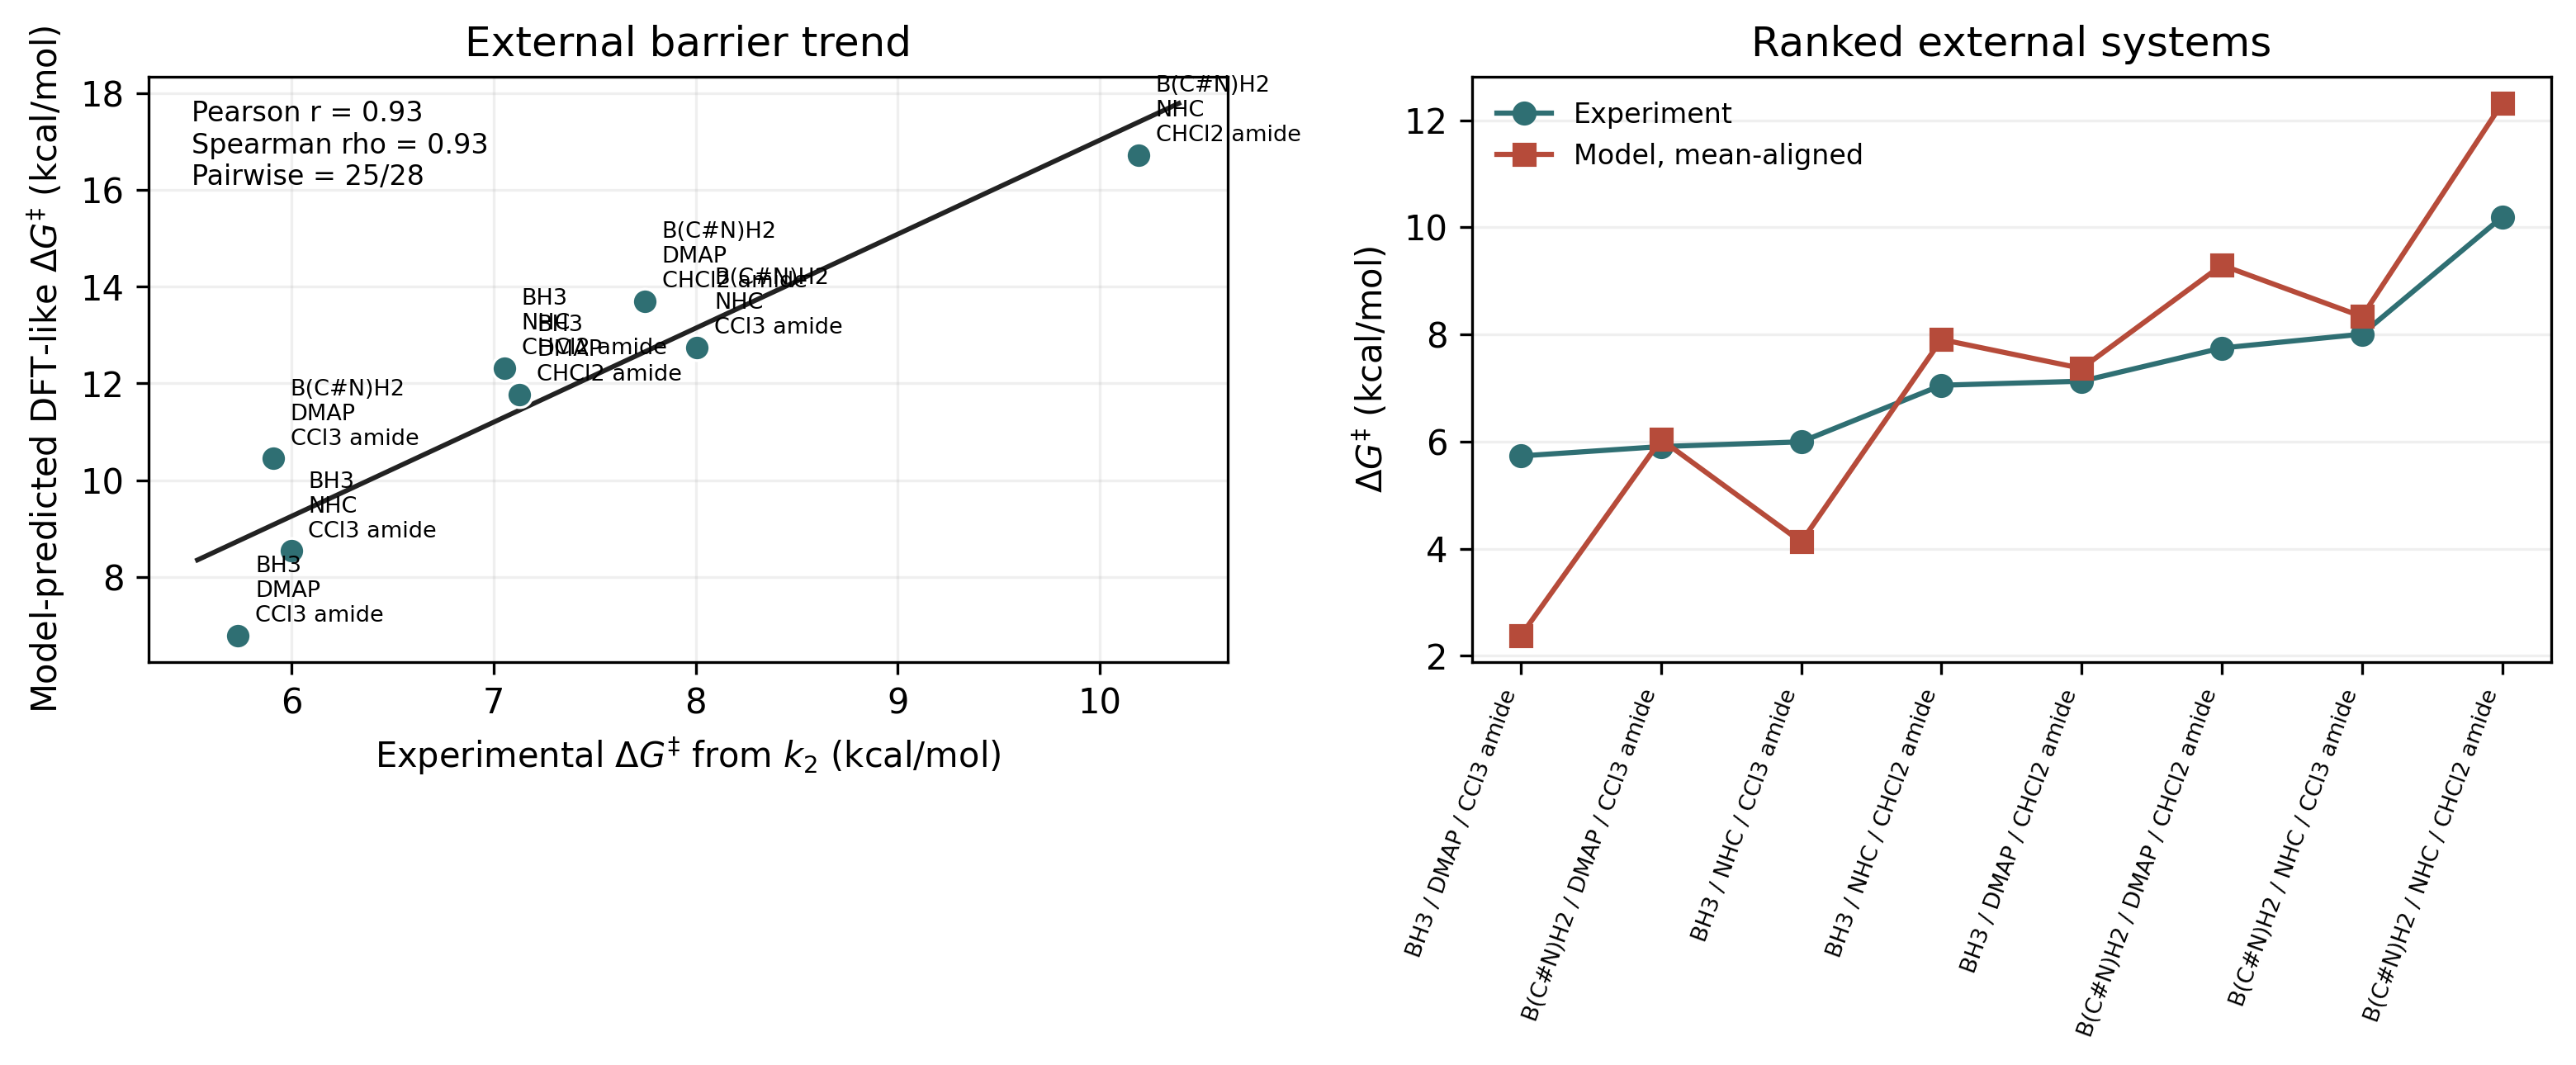

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4), dpi=300)

ax = axes[0]
x = exp_results["deltaGa_exp(kcal/mol)"].to_numpy()
y = exp_results["deltaGa_model(kcal/mol)"].to_numpy()
ax.scatter(x, y, s=54, color="#2F6F73", edgecolor="white", linewidth=0.8, zorder=3)
fit = np.polyfit(x, y, deg=1)
fit_x = np.linspace(x.min() - 0.2, x.max() + 0.2, 100)
ax.plot(fit_x, fit[0] * fit_x + fit[1], color="#222222", linewidth=1.4)
for _, row in exp_results.iterrows():
    ax.annotate(
        f"{row['B_label']}\n{row['LB_label']}\n{row['Cl_label']}",
        (row["deltaGa_exp(kcal/mol)"], row["deltaGa_model(kcal/mol)"]),
        textcoords="offset points",
        xytext=(5, 4),
        fontsize=6.5,
    )
ax.set_xlabel(r"Experimental $\Delta G^{\ddagger}$ from $k_2$ (kcal/mol)")
ax.set_ylabel(r"Model-predicted DFT-like $\Delta G^{\ddagger}$ (kcal/mol)")
ax.set_title("External barrier trend")
ax.text(
    0.04,
    0.96,
    f"Pearson r = {pearson_r:.2f}\nSpearman rho = {spearman_rho:.2f}\nPairwise = {pair_correct}/{pair_total}",
    transform=ax.transAxes,
    va="top",
    fontsize=8,
)
ax.grid(alpha=0.2)

ax = axes[1]
rank_df = exp_results.sort_values("deltaGa_exp(kcal/mol)").reset_index(drop=True)
ax.plot(
    np.arange(len(rank_df)),
    rank_df["deltaGa_exp(kcal/mol)"],
    marker="o",
    color="#2F6F73",
    label="Experiment",
)
ax.plot(
    np.arange(len(rank_df)),
    rank_df["deltaGa_model_mean_aligned(kcal/mol)"],
    marker="s",
    color="#B64B3A",
    label="Model, mean-aligned",
)
ax.set_xticks(np.arange(len(rank_df)))
ax.set_xticklabels(rank_df["system_label"], rotation=70, ha="right", fontsize=6.5)
ax.set_ylabel(r"$\Delta G^{\ddagger}$ (kcal/mol)")
ax.set_title("Ranked external systems")
ax.legend(frameon=False, fontsize=8)
ax.grid(axis="y", alpha=0.2)

fig.tight_layout()
figure_path = FIGURE_DIR / "JACS_experiment_external_validation.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
print("Saved", figure_path)
plt.show()


## Notes for the Revision

- `deltaGa_exp(kcal/mol)` is derived directly from the reported second-order rate constants, so the comparison is independent of the DFT transition-state calculations used for model training.
- Cl 723 and 724 are added only to the augmented working database under `output/jacs_experiment/`; the released `BorylXAT-DB.db` is not overwritten.
- The trend metrics are the primary external validation target because the CatBoost model predicts DFT-like barriers, while the literature rates include experimental and medium-specific effects.
